# Week 2 - Day 2: Probability & Distributions Lab
## Coin Flip Simulation, Normal Distribution, and Conditional Probability

## Step 1: Coin Flip Simulation

The goal of this step is to empirically verify the "Law of Large Numbers":
when a fair coin is flipped a very large number of times, the proportion 
of "Heads" outcomes gets closer and closer to the theoretical probability 
of 0.5.

We will use np.random.choice to simulate 10,000 flips, where each flip 
returns either 0 or 1 with equal probability (50%).

In [2]:
import numpy as np

np.random.seed(42)  # ensures reproducible results

n_flips = 10000
flips = np.random.choice([0, 1], size=n_flips, p=[0.5, 0.5])  # 0=Tails, 1=Heads

proportion_heads = np.mean(flips)
print(f"Number of flips: {n_flips}")
print(f"Proportion of Heads: {proportion_heads:.4f}")
print(f"Theoretical probability: 0.5")
print(f"Difference: {abs(proportion_heads - 0.5):.4f}")

Number of flips: 10000
Proportion of Heads: 0.4924
Theoretical probability: 0.5
Difference: 0.0076


## Step 2: Normal Distribution

We will generate 10,000 random values from a normal (Gaussian) distribution 
with a mean of 0 and a standard deviation of 1, using np.random.normal.

We then plot a histogram of these values to visually confirm that they 
follow the well-known symmetric bell-shaped curve centered around the mean — 
the shape that many statistical methods and machine learning assumptions 
rely on.

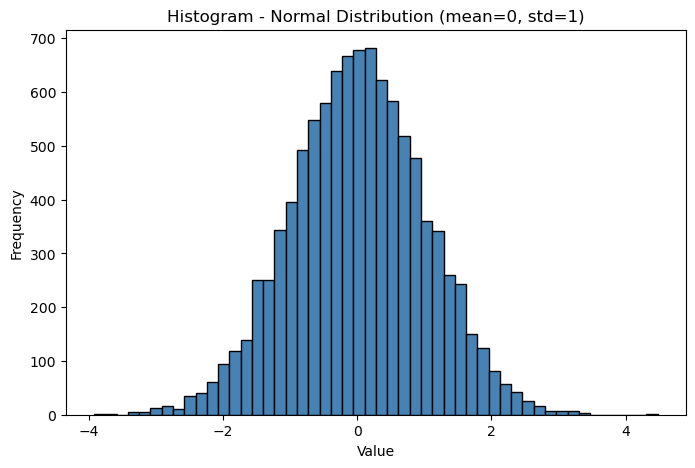

Sample mean: 0.0124
Sample standard deviation: 0.9997


In [3]:
import matplotlib.pyplot as plt

mean = 0
std_dev = 1
n_samples = 10000

normal_data = np.random.normal(loc=mean, scale=std_dev, size=n_samples)

plt.figure(figsize=(8, 5))
plt.hist(normal_data, bins=50, color="steelblue", edgecolor="black")
plt.title("Histogram - Normal Distribution (mean=0, std=1)")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

print(f"Sample mean: {np.mean(normal_data):.4f}")
print(f"Sample standard deviation: {np.std(normal_data):.4f}")

## Step 3: Conditional Probability

**Scenario:** A box contains 100 balls:
- 60 red balls
- 40 blue balls
Of the red balls, 30 are numbered
Of the blue balls, 10 are numbered

**Question:** If we pick a random ball and know it is numbered (B), 
what is the probability that it is red (A)? In other words, we want P(A|B).

**Manual Solution:**
- P(A and B) = P(red and numbered) = 30/100 = 0.30
- P(B) = P(numbered) = (30+10)/100 = 0.40
- P(A|B) = P(A and B) / P(B) = 0.30 / 0.40 = **0.75**

We will now verify this result through a practical simulation in Python.

In [5]:
np.random.seed(1)

n_balls = 100000  

is_red = np.random.choice([1, 0], size=n_balls, p=[0.6, 0.4])

is_numbered = np.zeros(n_balls)
is_numbered[is_red == 1] = np.random.choice([1, 0], size=(is_red == 1).sum(), p=[0.5, 0.5])
is_numbered[is_red == 0] = np.random.choice([1, 0], size=(is_red == 0).sum(), p=[0.25, 0.75])

numbered_balls = is_red[is_numbered == 1]
simulated_prob = np.mean(numbered_balls)

manual_prob = 0.30 / 0.40

print(f"Manually calculated P(A|B): {manual_prob:.4f}")
print(f"Simulated P(A|B): {simulated_prob:.4f}")
print(f"Difference: {abs(manual_prob - simulated_prob):.4f}")

Manually calculated P(A|B): 0.7500
Simulated P(A|B): 0.7471
Difference: 0.0029
